In [30]:
import pdb
import glob
import xarray as xr
import inversion_tools

In [37]:
pdir = '/work/noaa/co2/aschuh/WOMBAT_stuff/wombat-v3-forward/3a_transport_gc/intermediates/runs'
cdir = 'climatology_20140901_part001'
tracer = 'SpeciesConcVV_r0001p001s004'
#^^ocean_intercept_regionRegion14

rdirs = sorted(glob.glob(f'{pdir}/{cdir}_split*'))
for i in range(len(rdirs)):
    if(i>0): continue
    print(f'--------i={i+1}/{len(rdirs)}', end='\n')
    files = glob.glob(f'{rdirs[i]}/OutputDir/*Species*')
    for j in range(len(files)):
        print(f'j={j+1}/{len(files)}', end='\r')
        if j==0:
            data = xr.open_dataset(files[j])[tracer]
        else:
            data = xr.concat([data, xr.open_dataset(files[j])[tracer]], 'time')

--------i=1/29


In [41]:
print('resampling')
data = data.sortby('time')
daily = data.resample(time="1D").mean()

resampling


In [42]:
idir  = '/work/noaa/co2/jhollo/processed_transport_data/tmp/'
print('getting vertical average')
dd    = inversion_tools.column_average(daily, outfile=f'{idir}/tmp.nc')

getting vertical average


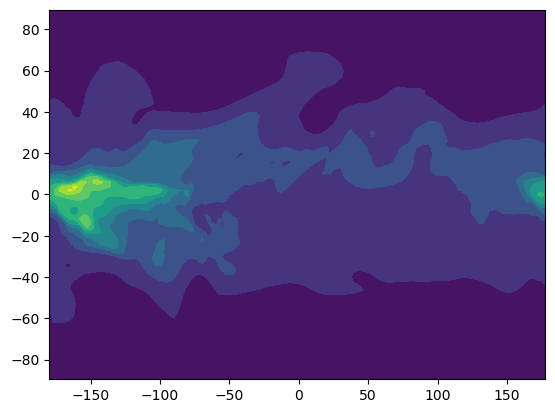

In [49]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.contourf(dd.lon, dd.lat, dd.isel(time=121), levels=10)